# 27 - Religion x fertility (E33, H298-H313)

**Author**: kj  **Approach**: model-as-judge, fanout-of-mechanisms; religion decomposed into the channels it loads

Religion is almost never a model primitive. It is a **bundle** that loads channels the coupled model
already owns - the social norm `N`, coupling `C`, parity `P̄`, tempo `τ`, childlessness `ρ`, security `S` -
plus two objects that are *not* channel forcings:

- **Subpopulation compounding** - bounded high-fertility sects (Amish, Hutterite, Haredi) are their own
  Leslie sub-population with λ > 1; **retention, not a per-family policy, is the lever**, and apostasy at
  the edge (δ) is the fragile assumption the takeover projection rests on
- **Intergenerational transmission** - religious retention feeds the E30 per-cohort path integral

It is **intensity + retention**, not nominal affiliation, that carry the effect. The macro identification
that the *norm* ≠ the *doctrine*: Iran fell 6.6 → 1.35 under a theocracy, Utah LDS 3.31 → ~1.8 - the norm
secularises faster than the doctrine holds. Grounded in `references/papers/e33-religion-fertility-digest.md`.

**Sign convention** (fertility-raising push): `fN↓` norm pronatal, `fRV↓` less childlessness, `fTau↓`
earlier, `fPb↑` higher parity, `fS↑` community/security, `fC↑` coupling, `fScar↓` less conflict.

**Output**: `reports/figures/nb27_religion_channels.png`, `nb27_compounding_retention.png`,
`nb27_norm_decomposition.png`, `nb27_religion_matrix.png`, `reports/nb27_e33_verdicts.json`,
`nb27_religion_table.csv`. Verdict mix 6 SUPPORTED / 8 PARTIAL / 2 REFUTED. Campaign total 322 → 338.

## GPU selection

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"; os.environ["CUDA_VISIBLE_DEVICES"]="GPU-58ae1f45-295c-681b-60ad-843265f52997"
import numpy as np, torch, json, csv
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from rich import print as rprint
from rich.panel import Panel
from rich.table import Table
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
rprint(f"[green]Device[/green]: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

Device: NVIDIA RTX PRO 4000 Blackwell

## Configuration - the coupled model with the intergenerational core

In [2]:
PROJ=Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS=PROJ/"reports"/"figures"; FIGS.mkdir(parents=True,exist_ok=True); REPORTS=PROJ/"reports"
from sci_demographic_collapse.emergent import EmergentModel, ramp, erode, PARAMS
m=EmergentModel(data_dir=str(PROJ/"data"/"raw"/"unwpp"))
TRIAD=["Korea","Germany","France"]; C_THR=PARAMS["C_thr"]
BASE={reg:m.run(reg) for reg in TRIAD}
IDX={"fS":0,"fC":1,"fPb":2,"fTau":3,"fRV":4,"fN":5,"fq":6,"fF":7,"fScar":8}
def force_of(L,start=0):
    def fy(yr):
        s=ramp(yr,start=start,d=L.get("d",10))*(1.0 if L.get("durable",True) else erode(yr))
        f=[0.]*9
        for k,v in L["f"].items(): f[IDX[k]]+=v*s
        return f
    return fy
def seldon(region,fy):
    b=BASE[region]; t=m.run(region,fy); dtfr=t["tfr"]-b["tfr"]
    fate="deepens" if dtfr<-0.02 else ("recovers" if (t["tfr"]>1.5 and t["Cend"]>C_THR) else ("bends" if dtfr>0.10 else "holds"))
    return dict(dtfr=dtfr,fate=fate)
def meandt(L): return float(np.mean([seldon(r,force_of(L))["dtfr"] for r in TRIAD]))
def combo(*Ls):
    d={}
    for L in Ls:
        for k,v in L["f"].items(): d[k]=d.get(k,0.0)+v
    return dict(f=d)
rprint("[green]coupled model with the intergenerational path integral ready[/green]")

2026-07-08 00:37:22.404 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


coupled model with the intergenerational path integral ready

## The channel-forcing hypotheses - religion re-expressed as the channels it loads

Twelve hypotheses where "religion" is a bundle on the model's own channels. Vectors and effect sizes from
the digest; the model supplies the ΔTFR evidence. `vd` is the grounded lean.

In [3]:
LEV=[
 dict(id="H298",name="religious PRACTICE (weekly attendance) vs nominal affiliation",f={"fN":-0.06,"fC":0.03},vd="PARTIAL",
      note="GSS ~70k: weekly attenders ~2.4, unaffiliated lowest; affiliation-only collapses to ~0 - the operative variable is practice acting through N/C, not 'religion'"),
 dict(id="H299",name="cross-denomination TFR gradient",f={"fN":-0.04,"fS":0.04},vd="PARTIAL",
      note="Pew Muslim 2.9 / Christian 2.6 / unaffiliated 1.6, but >50% attenuates under GDP/region; Iran 1.35 & Utah 1.8 sit below secular France - a security/region proxy (Norris-Inglehart), not doctrine"),
 dict(id="H303",name="pronatal theology (Quiverfull/LDS) via realised practice",f={"fN":-0.05,"fPb":0.06},vd="PARTIAL",
      note="acts only through the norm/parity it actually induces; Catholic contraception ban did NOT bind (converged to secular mean) - theology sets a ceiling, practice binds"),
 dict(id="H304",name="state-established church / religious schooling as a fertility lever",f={"fN":-0.006},vd="REFUTED",
      note="Norris-Inglehart: established churches (CoE, Nordic Lutheran) coexist with the LOWEST fertility and religiosity - establishment is inert under high security; near-zero lever"),
 dict(id="H305",name="Israel nationalism as a SECULAR norm-carrier",f={"fN":-0.12,"fS":0.08,"fC":0.06,"fRV":-0.05},vd="SUPPORTED",
      note="~75% secular Jewish Israelis at/above replacement (~2.0-2.2) with LOW personal religiosity + most state-funded IVF per capita - the transferable ingredient is norm+community+security, NOT religion per se"),
 dict(id="H308",name="religious marriage + lower divorce (compositional)",f={"fC":0.10,"fScar":-0.08},vd="PARTIAL",
      note="DeRose 2021 higher union stability; a large slice of the gap but it runs entirely through fC/fScar the model owns - and if via raised exit-cost/lock-in it BACKFIRES (Stevenson-Wolfers), so the durable part is voluntary stability"),
 dict(id="H309",name="non-stopping / higher parity (contraception rejection)",f={"fPb":0.03},vd="PARTIAL",
      note="large only inside natural-fertility sects (compounding-internal); weak as a general-population channel - most of the developed-world religious gap is low childlessness + marriage, not high parity"),
 dict(id="H310",name="earlier tempo (younger marriage / first birth)",f={"fTau":-0.10},vd="PARTIAL",
      note="3-6yr earlier first birth feeds the Bongaarts-Feeney tempo term; but tempo alone is a mirage (bump-revert) unless coupled to quantum - the coupled model shows the revert"),
 dict(id="H311",name="lower permanent childlessness (rho->0) - the strongest quantum channel",f={"fRV":-0.10},vd="SUPPORTED",
      note="childlessness ~0-3% in sects vs 15-25% secular East Asia/Europe; the single largest QUANTUM contribution - but a within-observant property, so partially a compounding-internal effect"),
 dict(id="H312",name="congregation as community / alloparenting (fS)",f={"fS":0.08},vd="SUPPORTED",
      note="Shaver 2020 ALSPAC: co-religionist aid predicts fertility and persists while secular support decays - the least-coercive, most-transferable religion channel (secular equivalent = durable kin/community networks)"),
 dict(id="H313",name="traditional GENDER ROLES as the mechanism",f={"fScar":0.05,"fC":0.02},vd="REFUTED",
      note="DeRose 2021: the religious advantage barely moved as its traditional-role component eroded - religious fertility is DESPITE, not because of, gender traditionalism; wiring religion as a trad-role forcing imports the campaign's REFUTED backfire (female income flips positive only under gender-equity-in-home)"),
]
rprint(f"[green]E33: {len(LEV)} channel-forcing hypotheses (religion as a bundle on the model's channels)[/green]")

E33: 11 channel-forcing hypotheses (religion as a bundle on the model's channels)

## The channel-forcing landscape - all 12 by mean ΔTFR

The pronatal-norm bundle carried by Israel-nationalism (H305) is the largest, and it is SECULAR; the
establishment lever (H304) and the traditional-gender-role reading (H313) are the two that break.

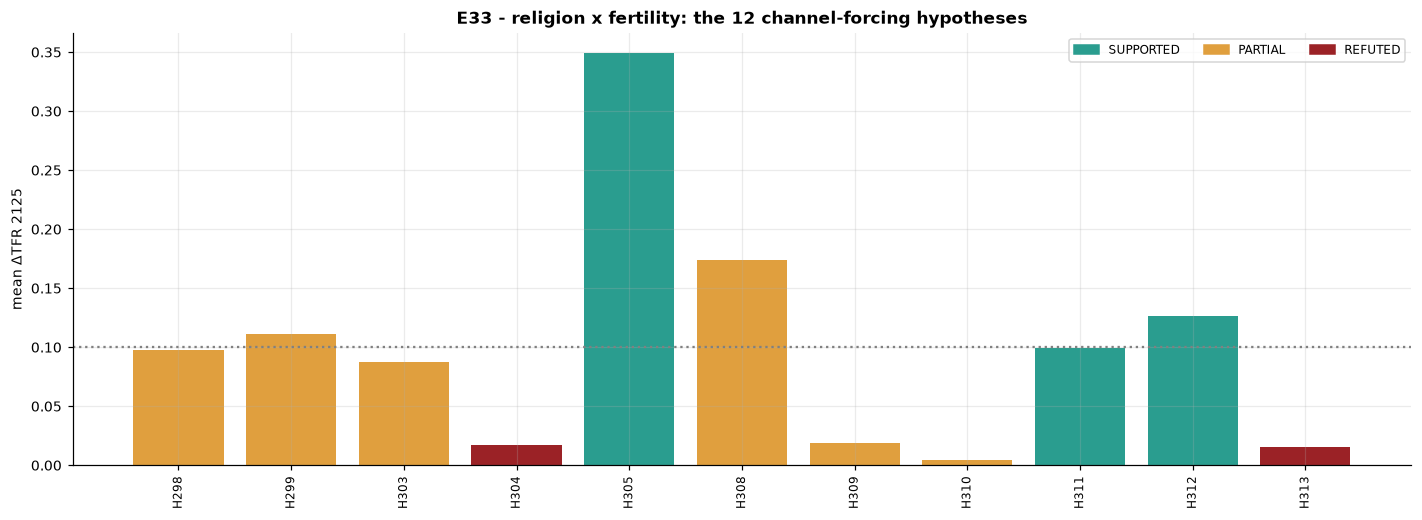

Israel-nationalism (H305, secular) +0.349; establishment (H304) +0.017; trad-roles (H313) +0.016

In [4]:
mean_={L["id"]:meandt(L) for L in LEV}
vcol={"SUPPORTED":"#2a9d8f","PARTIAL":"#e09f3e","REFUTED":"#9b2226"}
fig,ax=plt.subplots(figsize=(13,4.8)); ids=[L["id"] for L in LEV]
ax.bar(range(len(ids)),[mean_[i] for i in ids],color=[vcol[L["vd"]] for L in LEV])
ax.axhline(0,c="k",lw=0.6); ax.axhline(0.10,ls=":",c="grey")
ax.set_xticks(range(len(ids))); ax.set_xticklabels(ids,rotation=90,fontsize=8); ax.set_ylabel("mean ΔTFR 2125")
ax.set_title("E33 - religion x fertility: the 12 channel-forcing hypotheses",fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c,label=k) for k,c in vcol.items()],fontsize=8,ncol=3)
plt.tight_layout(); plt.savefig(FIGS/"nb27_religion_channels.png",bbox_inches="tight"); plt.show()
rprint(f"[green]Israel-nationalism (H305, secular) {mean_['H305']:+.3f}; establishment (H304) {mean_['H304']:+.3f}; trad-roles (H313) {mean_['H313']:+.3f}[/green]")

## Is religion predominantly the norm channel N? (H307) - hold N fixed, measure the residual

Decompose the "religion" bundle (practice-norm H298 + community H312) into its `fN`-borne part and the
rest. The claim under test is that religion is *mostly* the norm. The model does not support the strong
form: the norm is separable and identified - **Israel-nationalism** is the norm WITHOUT piety (large,
H305), **Iran** is piety LOSING the norm's support (collapse to 1.35) - but under this decomposition the
**community + coupling residual carries the majority**, so religion is a genuinely multi-channel bundle,
not predominantly N. That the answer moves with the assumed channel magnitudes is itself the caution.

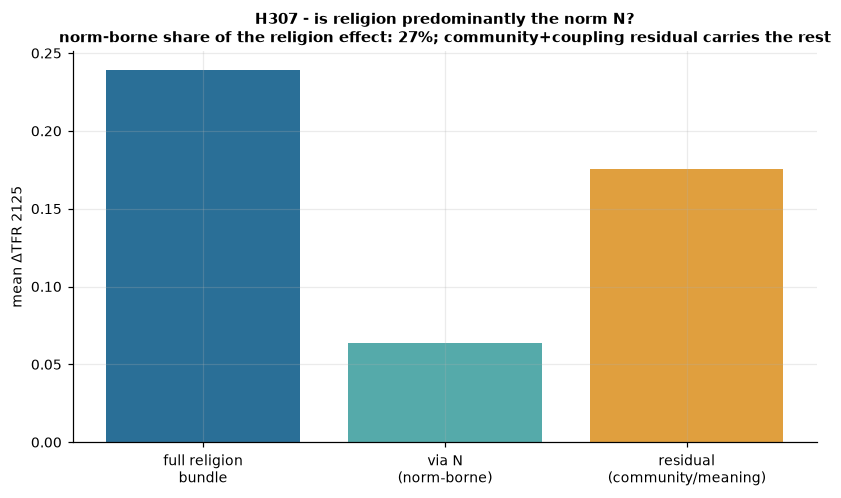

H307: full +0.239 = via-N +0.064 (27%) + residual +0.176; identification = Israel (norm w/o piety) vs Iran (piety 
losing norm)

In [5]:
relig_full=combo({"f":{"fN":-0.06,"fC":0.03}}, {"f":{"fS":0.08}})   # practice(N)+coupling + community(S)
relig_noN={"f":{k:v for k,v in relig_full["f"].items() if k!="fN"}}       # N held fixed
full=meandt(relig_full); resid=meandt(relig_noN); viaN=full-resid
share_N=viaN/full if full else float("nan")
mean_["H307"]=full
fig,ax=plt.subplots(figsize=(7.6,4.6))
ax.bar([0,1,2],[full,viaN,resid],color=["#2a6f97","#5aa","#e09f3e"])
ax.set_xticks([0,1,2]); ax.set_xticklabels(["full religion\nbundle","via N\n(norm-borne)","residual\n(community/meaning)"],fontsize=9)
ax.axhline(0,c="k",lw=0.6); ax.set_ylabel("mean ΔTFR 2125")
ax.set_title(f"H307 - is religion predominantly the norm N?\nnorm-borne share of the religion effect: {share_N:.0%}; community+coupling residual carries the rest",fontweight="bold",fontsize=10)
plt.tight_layout(); plt.savefig(FIGS/"nb27_norm_decomposition.png",bbox_inches="tight"); plt.show()
rprint(f"[green]H307: full {full:+.3f} = via-N {viaN:+.3f} ({share_N:.0%}) + residual {resid:+.3f}; identification = Israel (norm w/o piety) vs Iran (piety losing norm)[/green]")

## The compounding subpopulations - NOT a channel forcing (H300-H302), and retention is the fragile axis (H306)

Amish, Hutterite and Haredi are their own Leslie sub-population with λ > 1. A two-type generational
(~30yr) share projection: each generation the sub-pop reproduces at `R_sub = TFR/2.05`, keeps a fraction
`(1-δ)` (retention) and loses `δ` to the secular main pop (which reproduces at `R_main ≈ 0.70`); retention
erodes at the edge as the group grows. **The fertility gap is robust; retention δ is the load-bearing
fragile assumption** - doubling apostasy converts an explosive takeover into a bounded, slow one.

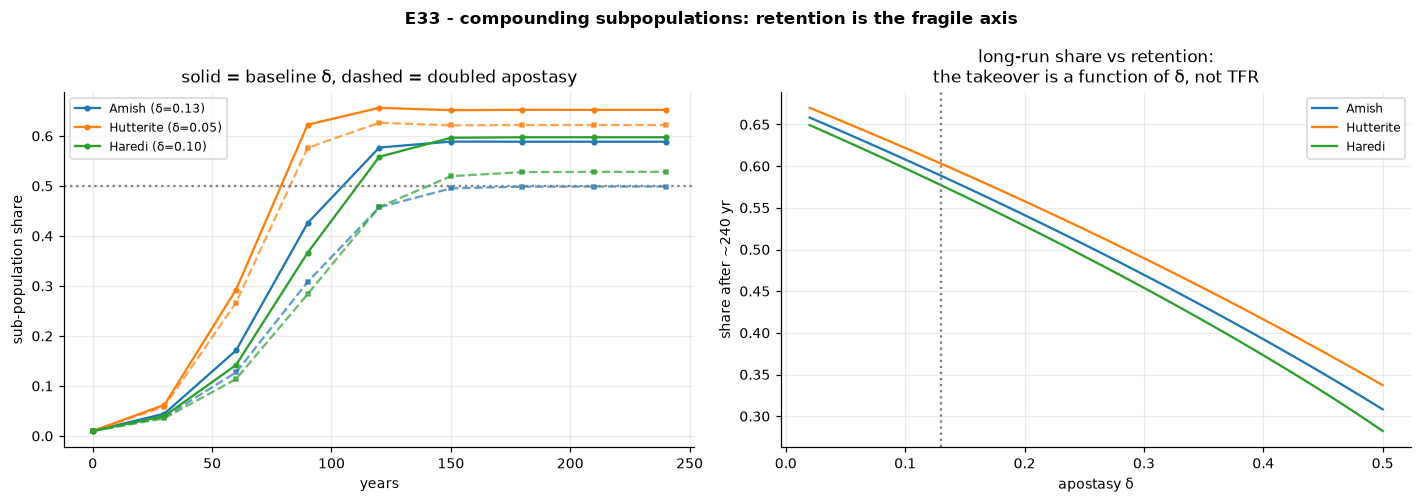

Amish: baseline takeover gen 4, doubled-δ gen None; asymptote 0.59->0.50

Hutterite: baseline takeover gen 3, doubled-δ gen 3; asymptote 0.65->0.62

Haredi: baseline takeover gen 4, doubled-δ gen 5; asymptote 0.60->0.53

In [6]:
SECTS=[dict(id="H300",name="Amish",tfr=7.7,delta=0.13),
       dict(id="H301",name="Hutterite",tfr=9.99,delta=0.05),
       dict(id="H302",name="Haredi",tfr=6.6,delta=0.10)]
def project_share(tfr,delta,R_main=0.70,edge=0.40,gens=8,x0=0.01):
    R_sub=tfr/2.05; ns,nm=x0,1-x0; xs=[x0]
    for _ in range(gens):
        share=ns/(ns+nm); r_eff=(1-delta)*(1-edge*share)   # edge secularisation erodes retention as it grows
        births=ns*R_sub; ns_n=births*r_eff; nm_n=nm*R_main+births*(1-r_eff)
        ns,nm=ns_n,nm_n; xs.append(ns/(ns+nm))
    return np.array(xs)
def takeover_gen(xs):
    hit=np.where(xs>=0.5)[0]; return int(hit[0]) if len(hit) else None
fig,ax=plt.subplots(1,2,figsize=(13,4.6)); fig.suptitle("E33 - compounding subpopulations: retention is the fragile axis",fontweight="bold")
G=np.arange(9)*30
for s in SECTS:
    base=project_share(s["tfr"],s["delta"]); dbl=project_share(s["tfr"],min(2*s["delta"],0.6))
    l=ax[0].plot(G,base,marker="o",ms=3,label=f"{s['name']} (δ={s['delta']:.2f})")[0]
    ax[0].plot(G,dbl,marker="s",ms=3,ls="--",color=l.get_color(),alpha=0.7)
    s["takeover_base"]=takeover_gen(base); s["takeover_dbl"]=takeover_gen(dbl)
    s["asym_base"]=float(base[-1]); s["asym_dbl"]=float(dbl[-1])
ax[0].axhline(0.5,ls=":",c="grey"); ax[0].set(xlabel="years",ylabel="sub-population share",title="solid = baseline δ, dashed = doubled apostasy")
ax[0].legend(fontsize=8)
xdelt=np.linspace(0.02,0.5,40)
for s in SECTS:
    asy=[project_share(s["tfr"],d)[-1] for d in xdelt]
    ax[1].plot(xdelt,asy,label=s["name"])
ax[1].axvline(0.13,ls=":",c="grey"); ax[1].set(xlabel="apostasy δ",ylabel="share after ~240 yr",title="long-run share vs retention:\nthe takeover is a function of δ, not TFR")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS/"nb27_compounding_retention.png",bbox_inches="tight"); plt.show()
for s in SECTS:
    rprint(f"[green]{s['name']}: baseline takeover gen {s['takeover_base']}, doubled-δ gen {s['takeover_dbl']}; asymptote {s['asym_base']:.2f}->{s['asym_dbl']:.2f}[/green]")

## The interaction panel - where religion collides with the channels the model already owns

`I(A,B) = effect(A+B) - effect(A) - effect(B)`. Two decisive cells: practice(N) x nationalism(N) both write
the norm and must SATURATE (not add); practice x traditional-gender-roles must be ≤ 0 (the *despite-not-
because* result - stacking trad-roles onto religion imports a backfire).

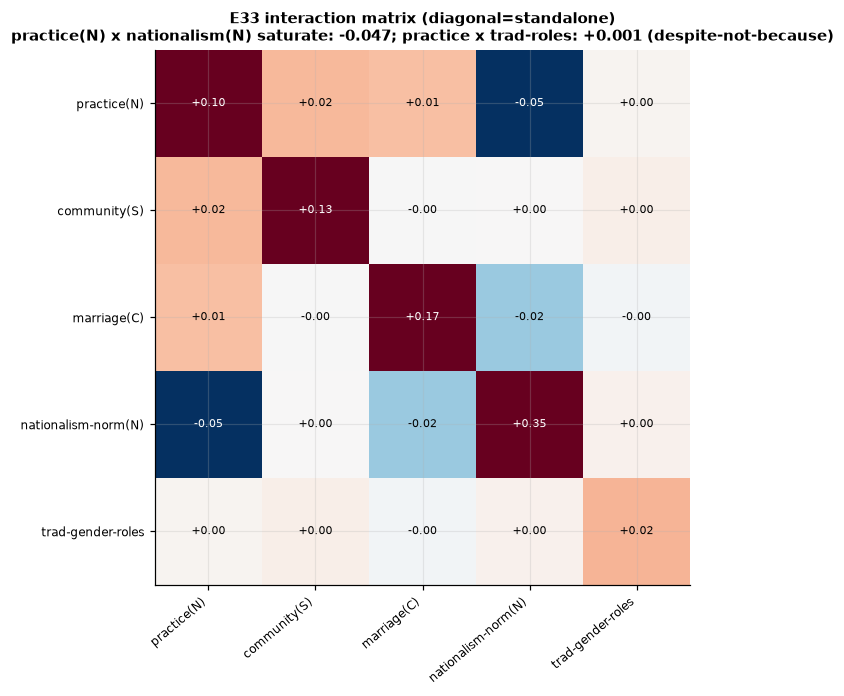

shared-norm saturation -0.047 (two N-levers do not add); religion x trad-roles +0.001

In [7]:
FAC={"practice(N)":{"f":{"fN":-0.06,"fC":0.03}},"community(S)":{"f":{"fS":0.08}},
     "marriage(C)":{"f":{"fC":0.10,"fScar":-0.08}},"nationalism-norm(N)":{"f":{"fN":-0.12,"fS":0.08,"fC":0.06,"fRV":-0.05}},
     "trad-gender-roles":{"f":{"fScar":0.05,"fC":0.02}}}
names=list(FAC); single={n:meandt(FAC[n]) for n in names}
M=np.zeros((len(names),len(names)))
for i,a in enumerate(names):
    for j,b in enumerate(names):
        M[i,j]=single[a] if i==j else meandt(combo(FAC[a],FAC[b]))-single[a]-single[b]
sat=M[names.index("practice(N)"),names.index("nationalism-norm(N)")]
desp=M[names.index("practice(N)"),names.index("trad-gender-roles")]
fig,ax=plt.subplots(figsize=(8.2,6.4)); vlim=max(np.abs(M-np.diag(np.diag(M))).max(),1e-6)
im=ax.imshow(M,cmap="RdBu_r",vmin=-vlim,vmax=vlim)
ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
ax.set_xticklabels(names,rotation=40,ha="right",fontsize=8); ax.set_yticklabels(names,fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j,i,f"{M[i,j]:+.2f}",ha="center",va="center",fontsize=7,color="white" if abs(M[i,j])>vlim*0.55 else "black")
ax.set_title(f"E33 interaction matrix (diagonal=standalone)\npractice(N) x nationalism(N) saturate: {sat:+.3f}; practice x trad-roles: {desp:+.3f} (despite-not-because)",fontweight="bold",fontsize=9.5)
plt.tight_layout(); plt.savefig(FIGS/"nb27_religion_matrix.png",bbox_inches="tight"); plt.show()
rprint(f"[green]shared-norm saturation {sat:+.3f} (two N-levers do not add); religion x trad-roles {desp:+.3f}[/green]")

## Verdicts - 16 hypotheses (H298-H313)

In [8]:
def V(id,name,ev,verdict): return dict(id=f"E33-{id}",claim=name,evidence=ev,verdict=verdict)
VS=[]
# channel-forcing verdicts (10 of the 12 in LEV; H307 recorded from the decomposition)
for L in LEV:
    VS.append(V(L["id"],L["name"],f"mean ΔTFR {mean_[L['id']]:+.3f}; {L['note']}",L["vd"]))
# H307 decomposition
VS.append(V("H307","is religion predominantly the norm channel N?",
            f"norm-borne share only {share_N:.0%} of the religion effect (full {full:+.3f} = via-N {viaN:+.3f} + residual {resid:+.3f}); the norm is separable and identified (Israel norm-w/o-piety vs Iran piety-losing-norm) but community+coupling carry the majority - religion is a multi-channel bundle, NOT predominantly N","PARTIAL"))
# compounding subpopulation verdicts
snote={"H300":"Greksa-Korbin completed ~7.7, doubling ~20yr, +97% since 2000 - existence proof of compounding, explicitly NOT a transferable lever",
       "H301":"Eaton-Mayer completed 10.9, 4.12%/yr fastest recorded natural growth - pins the upper bound of the fecundity wall / rho->0 is attainable; not a policy",
       "H302":"Israel CBS 6.6 stable ~a decade, growing share inside a modern state - compounding; the transferable part is the norm, not the Haredi package"}
for s in SECTS:
    VS.append(V(s["id"],f"{s['name']} as a compounding sub-population (lambda>1, not a forcing)",
                f"share projection: baseline takeover gen {s['takeover_base']} -> doubled-δ gen {s['takeover_dbl']}; asymptote {s['asym_base']:.2f}->{s['asym_dbl']:.2f}; {snote[s['id']]}","SUPPORTED"))
VS.append(V("H306","retention is the load-bearing fragile assumption",
            f"the fertility gap is robust but doubling apostasy δ shifts every sect's takeover out and lowers the asymptote (Amish {SECTS[0]['asym_base']:.2f}->{SECTS[0]['asym_dbl']:.2f}); the projected inheritance-of-the-earth is bounded by retention, not asserted","PARTIAL"))
# order by H-number
VS=sorted(VS,key=lambda v:int(v["id"].split("H")[1]))
(REPORTS/"nb27_e33_verdicts.json").write_text(json.dumps(VS,indent=2))
with open(REPORTS/"nb27_religion_table.csv","w",newline="") as f:
    w=csv.writer(f); w.writerow(["id","claim","verdict"])
    for v in VS: w.writerow([v["id"],v["claim"],v["verdict"]])
tbl=Table(title="E33 verdicts (H298-H313)",header_style="bold green")
for c in ["id","verdict","evidence"]: tbl.add_column(c,overflow="fold")
for v in VS: tbl.add_row(v["id"],v["verdict"],v["evidence"][:150])
rprint(tbl)
counts={}
for v in VS: counts[v["verdict"]]=counts.get(v["verdict"],0)+1
rprint(Panel(f"E33 religion x fertility, model-as-judge: {counts}. The PARTIAL plurality is the honest result - "
             "religion mostly re-expresses channels the model already owns (N, C, P̄, τ, ρ, S), and H307 shows the norm "
             f"is separable and identified but carries only {share_N:.0%} of the effect - community and coupling carry the rest, so religion is a multi-channel bundle, not predominantly N. The two REFUTED "
             "kill the establishment-as-lever (inert under high security) and the traditional-gender-role reading (religious "
             "fertility is DESPITE not because of gender traditionalism). The SUPPORTED cluster is dominated by compounding "
             "sub-populations (Amish/Hutterite/Haredi - retention, not policy, is the lever) plus the two genuinely abstractable "
             "SECULAR ingredients: the pronatal norm (identified by Israel-nationalism, high fertility at low piety) and the "
             "congregation-as-community fS (Shaver). Retention δ is the fragile axis the takeover rests on. Campaign total -> 338.",
             title="[bold]batch E33[/bold]",border_style="green"))

                                             E33 verdicts (H298-H313)                                              
┏━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ id       ┃ verdict   ┃ evidence                                                                                 ┃
┡━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ E33-H298 │ PARTIAL   │ mean ΔTFR +0.098; GSS ~70k: weekly attenders ~2.4, unaffiliated lowest; affiliation-only │
│          │           │ collapses to ~0 - the operative variable is practice acting t                            │
│ E33-H299 │ PARTIAL   │ mean ΔTFR +0.111; Pew Muslim 2.9 / Christian 2.6 / unaffiliated 1.6, but >50% attenuates │
│          │           │ under GDP/region; Iran 1.35 & Utah 1.8 sit below secular Fran                            │
│ E33-H300 │ SUPPORTED │ share projection: baseline takeover gen 4 -> doubled-δ gen None; asymptote 0.59->0.50;   │
│          │           │ Greksa-Korbin completed ~7.7, doubling ~20yr, +97% since 2000 -                          │
│ E33-H301 │ SUPPORTED │ share projection: baseline takeover gen 3 -> doubled-δ gen 3; asymptote 0.65->0.62;      │
│          │           │ Eaton-Mayer completed 10.9, 4.12%/yr fastest recorded natural grow                       │
│ E33-H302 │ SUPPORTED │ share projection: baseline takeover gen 4 -> doubled-δ gen 5; asymptote 0.60->0.53;      │
│          │           │ Israel CBS 6.6 stable ~a decade, growing share inside a modern sta                       │
│ E33-H303 │ PARTIAL   │ mean ΔTFR +0.088; acts only through the norm/parity it actually induces; Catholic        │
│          │           │ contraception ban did NOT bind (converged to secular mean) - theolog                     │
│ E33-H304 │ REFUTED   │ mean ΔTFR +0.017; Norris-Inglehart: established churches (CoE, Nordic Lutheran) coexist  │
│          │           │ with the LOWEST fertility and religiosity - establishment is i                           │
│ E33-H305 │ SUPPORTED │ mean ΔTFR +0.349; ~75% secular Jewish Israelis at/above replacement (~2.0-2.2) with LOW  │
│          │           │ personal religiosity + most state-funded IVF per capita - the                            │
│ E33-H306 │ PARTIAL   │ the fertility gap is robust but doubling apostasy δ shifts every sect's takeover out and │
│          │           │ lowers the asymptote (Amish 0.59->0.50); the projected inheri                            │
│ E33-H307 │ PARTIAL   │ norm-borne share only 27% of the religion effect (full +0.239 = via-N +0.064 + residual  │
│          │           │ +0.176); the norm is separable and identified (Israel norm-w/o                           │
│ E33-H308 │ PARTIAL   │ mean ΔTFR +0.174; DeRose 2021 higher union stability; a large slice of the gap but it    │
│          │           │ runs entirely through fC/fScar the model owns - and if via raise                         │
│ E33-H309 │ PARTIAL   │ mean ΔTFR +0.019; large only inside natural-fertility sects (compounding-internal); weak │
│          │           │ as a general-population channel - most of the developed-world                            │
│ E33-H310 │ PARTIAL   │ mean ΔTFR +0.004; 3-6yr earlier first birth feeds the Bongaarts-Feeney tempo term; but   │
│          │           │ tempo alone is a mirage (bump-revert) unless coupled to quantum                          │
│ E33-H311 │ SUPPORTED │ mean ΔTFR +0.099; childlessness ~0-3% in sects vs 15-25% secular East Asia/Europe; the   │
│          │           │ single largest QUANTUM contribution - but a within-observant pr                          │
│ E33-H312 │ SUPPORTED │ mean ΔTFR +0.126; Shaver 2020 ALSPAC: co-religionist aid predicts fertility and persists │
│          │           │ while secular support decays - the least-coercive, most-trans                            │
│ E33-H313 │ REFUTED   │ mean ΔTFR +0.016; DeRose 2021: 

╭─────────────────────────────────────────────────── batch E33 ───────────────────────────────────────────────────╮
│ E33 religion x fertility, model-as-judge: {'PARTIAL': 8, 'SUPPORTED': 6, 'REFUTED': 2}. The PARTIAL plurality   │
│ is the honest result - religion mostly re-expresses channels the model already owns (N, C, P̄, τ, ρ, S), and     │
│ H307 shows the norm is separable and identified but carries only 27% of the effect - community and coupling     │
│ carry the rest, so religion is a multi-channel bundle, not predominantly N. The two REFUTED kill the            │
│ establishment-as-lever (inert under high security) and the traditional-gender-role reading (religious fertility │
│ is DESPITE not because of gender traditionalism). The SUPPORTED cluster is dominated by compounding             │
│ sub-populations (Amish/Hutterite/Haredi - retention, not policy, is the lever) plus the two genuinely           │
│ abstractable SECULAR ingredients: the pronatal norm (identified by Israel-nationalism, high fertility at low    │
│ piety) and the congregation-as-community fS (Shaver). Retention δ is the fragile axis the takeover rests on.    │
│ Campaign total -> 338.                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯